# Session 2: Working with LLM Coding Agents

## Overview

This assignment explores how large language models function as coding agents within integrated development environments. You'll work with climate emissions data to understand both the capabilities and limitations of LLM-assisted data analysis, with particular attention to how execution environment shapes what's possible.

## Learning Objectives

Through structured exercises with the OWID CO2 dataset, you will:

- **Distinguish** between chat-based LLM interfaces and coding agents with local execution capabilities
- **Develop** fluency in specifying data operations through natural language while understanding the underlying computational patterns
- **Evaluate** the boundary between tasks coding agents handle autonomously versus those requiring human guidance
- **Assess** when programmatic approaches offer advantages over manual analysis methods

## The Execution Environment Question

The same foundation model—Claude Sonnet 4.5, GPT-4, or similar—exhibits markedly different capabilities depending on its execution context. A browser-based chat interface can generate syntactically correct code but lacks the infrastructure to execute, test, and refine it. The model generates a response and moves on.

In contrast, a coding agent operating within VS Code has access to a Python interpreter, your installed packages, the filesystem, and terminal. This enables an iterative cycle: execute code, parse errors or unexpected output, modify the approach, and re-execute. The model maintains context across this loop, accumulating information about what works in your specific environment.

This architectural difference—not model sophistication—determines whether you can request "analyze emissions trends by region" and receive working results, or whether you must manually execute generated code, diagnose failures, and prompt for corrections.

## Working with OWID Climate Data

Our World in Data maintains a comprehensive CO2 emissions dataset with country-level historical data, fuel source breakdowns, and economic indicators. The dataset's accessible format (direct CSV URL, documented schema, standard tabular structure) makes it appropriate for examining how coding agents handle common analytical workflows: filtering, aggregation, reshaping, and visualization.

Your role is to specify analyses in natural language and observe how the coding agent approaches each task. Note what it handles autonomously, where it requires clarification, what libraries it selects, and how it recovers from errors.

---
## Part 0: Setup

Import the necessary libraries for data manipulation and visualization. Request this from your coding agent and observe library selection.

In [1]:
import pandas as pd

url = "https://github.com/owid/co2-data/raw/master/owid-co2-data.csv"
df = pd.read_csv(url)

# Use display() so each is rendered regardless of position
from IPython.display import display

display(df.head())   # first few rows (HTML table)
df.info()            # column names, dtypes, non-null counts
display(df.shape)    # (rows, columns)

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 79 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    50411 non-null  object 
 1   year                                       50411 non-null  int64  
 2   iso_code                                   42480 non-null  object 
 3   population                                 41167 non-null  float64
 4   gdp                                        15251 non-null  float64
 5   cement_co2                                 29173 non-null  float64
 6   cement_co2_per_capita                      25648 non-null  float64
 7   co2                                        29384 non-null  float64
 8   co2_growth_abs                             27216 non-null  float64
 9   co2_growth_prct                            26239 non-null  float64
 10  co2_including_luc     

(50411, 79)

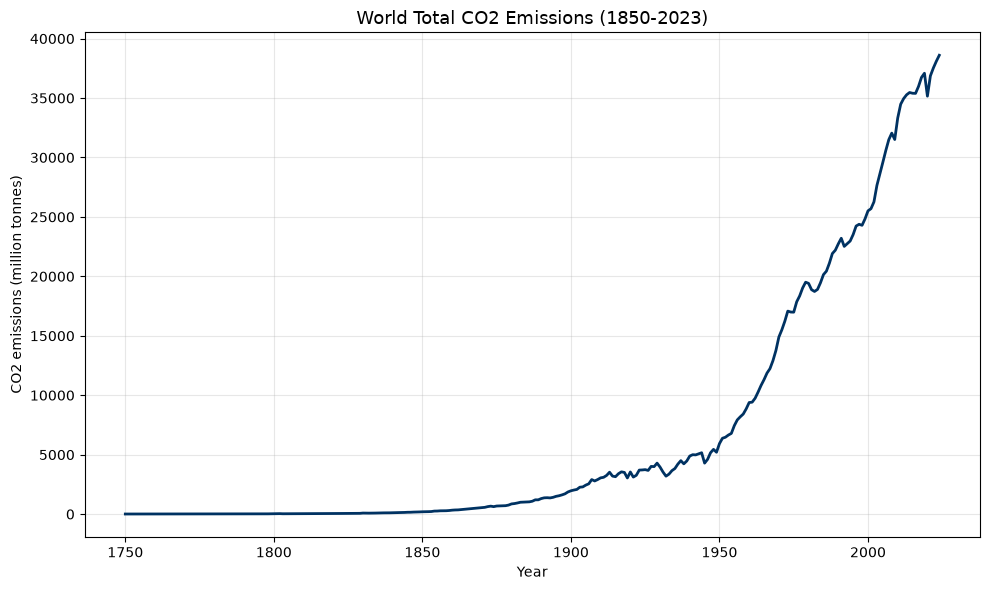

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the OWID CO2 dataset
url = "https://github.com/owid/co2-data/raw/master/owid-co2-data.csv"
df = pd.read_csv(url)

# --- World total CO2 emissions over time ---
world = df[df["country"] == "World"].dropna(subset=["co2"])

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(world["year"], world["co2"], linewidth=2, color="#003262")  # California Blue
ax.set_title("World Total CO2 Emissions (1850-2023)", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("CO2 emissions (million tonnes)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Part 1: Loading and Initial Exploration

### Task 1.1: Load and Explore

Load the OWID CO2 dataset: `https://github.com/owid/co2-data/raw/master/owid-co2-data.csv`

Request from your coding agent:
1. Load the data using appropriate library
2. Report dimensions (rows × columns)
3. Identify temporal coverage
4. Display sample rows
5. List emissions-related columns

In [3]:
import pandas as pd

# ------------------------------------------------------------------
# 1. Load the data (local cache first, URL fallback)
# ------------------------------------------------------------------
url = "https://github.com/owid/co2-data/raw/master/owid-co2-data.csv"
local_paths = ["notebooks/data/owid-co2-data.csv", "data/owid-co2-data.csv"]
path = next((p for p in local_paths if __import__("os").path.exists(p)), None)

if path:
    df = pd.read_csv(path)
    print(f"Loaded from local file: {path}")
else:
    df = pd.read_csv(url)
    print("Loaded from URL")

# ------------------------------------------------------------------
# 2. Dimensions
# ------------------------------------------------------------------
print(f"Dimensions: {df.shape[0]:,} rows x {df.shape[1]} columns")

# ------------------------------------------------------------------
# 3. Temporal coverage
# ------------------------------------------------------------------
print(f"\nTemporal coverage: {df['year'].min()} - {df['year'].max()}")
print(f"Unique years: {df['year'].nunique()}")
print(f"Unique countries/entities: {df['country'].nunique()}")

# ------------------------------------------------------------------
# 4. Sample rows
# ------------------------------------------------------------------
print("\nSample rows (head):")
print(df.head().to_string())

# ------------------------------------------------------------------
# 5. Emissions-related columns
# ------------------------------------------------------------------
emission_keywords = ["co2", "ghg", "methane", "nitrous", "flaring"]
emission_cols = [c for c in df.columns if any(k in c.lower() for k in emission_keywords)]
print(f"\nEmissions-related columns ({len(emission_cols)}):")
for c in emission_cols:
    print(f"  - {c}")

Loaded from local file: notebooks/data/owid-co2-data.csv
Dimensions: 50,411 rows x 79 columns

Temporal coverage: 1750 - 2024
Unique years: 275
Unique countries/entities: 254

Sample rows (head):
       country  year iso_code  population  gdp  cement_co2  cement_co2_per_capita  co2  co2_growth_abs  co2_growth_prct  co2_including_luc  co2_including_luc_growth_abs  co2_including_luc_growth_prct  co2_including_luc_per_capita  co2_including_luc_per_gdp  co2_including_luc_per_unit_energy  co2_per_capita  co2_per_gdp  co2_per_unit_energy  coal_co2  coal_co2_per_capita  consumption_co2  consumption_co2_per_capita  consumption_co2_per_gdp  cumulative_cement_co2  cumulative_co2  cumulative_co2_including_luc  cumulative_coal_co2  cumulative_flaring_co2  cumulative_gas_co2  cumulative_luc_co2  cumulative_oil_co2  cumulative_other_co2  energy_per_capita  energy_per_gdp  flaring_co2  flaring_co2_per_capita  gas_co2  gas_co2_per_capita  ghg_excluding_lucf_per_capita  ghg_per_capita  land_use_change_

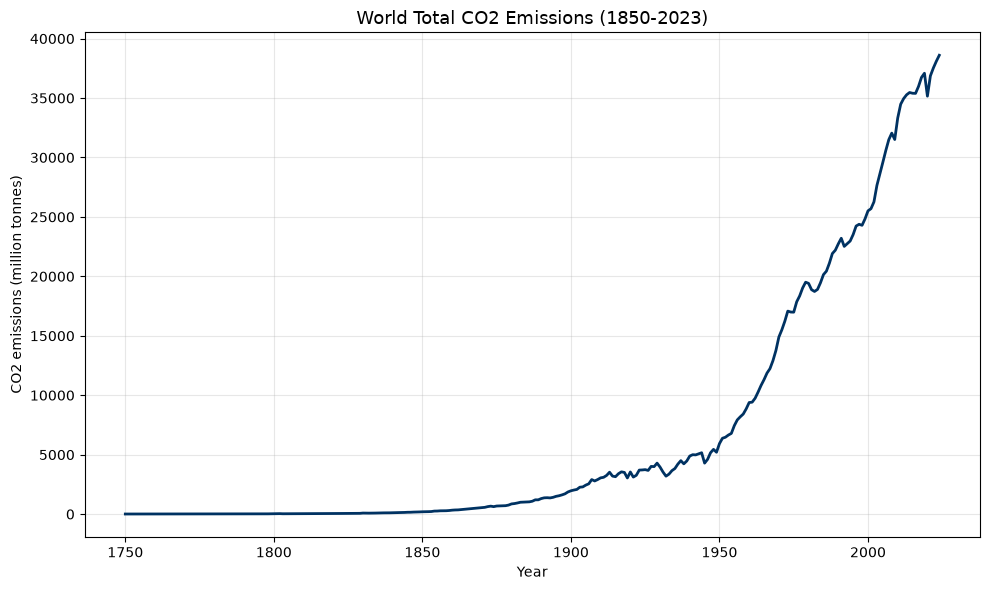

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the OWID CO2 dataset
url = "https://github.com/owid/co2-data/raw/master/owid-co2-data.csv"
df = pd.read_csv(url)

# --- World total CO2 emissions over time ---
world = df[df["country"] == "World"].dropna(subset=["co2"])

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(world["year"], world["co2"], linewidth=2, color="#003262")
ax.set_title("World Total CO2 Emissions (1850-2023)", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("CO2 emissions (million tonnes)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Task 1.2: Filtering and Ranking

Identify the top 5 CO2 emitting countries (not aggregate regions) in 2022.

**Note:** Dataset includes aggregate entities (World, continents, income groups). The coding agent needs to distinguish actual countries - observe whether it infers this from ISO codes or requires explicit guidance.

In [5]:
# Task 1.2 - Filtering and Ranking
# Top 5 CO2-emitting countries (not aggregate regions) in 2022.

# Real countries only: they carry an ISO code, aggregates do not
countries = df[df["iso_code"].notna()]

top5 = (
    countries[countries["year"] == 2022]
    .dropna(subset=["co2"])
    .nlargest(5, "co2")
    [["country", "iso_code", "co2", "co2_per_capita"]]
    .reset_index(drop=True)
)

print(top5.to_string(index=False))

      country iso_code       co2  co2_per_capita
        China      CHN 11711.808           8.218
United States      USA  5055.403          14.802
        India      IND  2831.132           1.986
       Russia      RUS  1675.461          11.509
        Japan      JPN  1029.645           8.237


In [6]:
# Task 1.2 - Your code here
# Filter to real countries only: they have ISO codes; aggregates do not
countries = df[df["iso_code"].notna()]

# 2022, sorted by total CO2 emissions descending
top5 = (
    countries[countries["year"] == 2022]
    .dropna(subset=["co2"])
    .nlargest(5, "co2")
    [["country", "co2"]]
    .reset_index(drop=True)
)

print(top5)

         country        co2
0          China  11711.808
1  United States   5055.403
2          India   2831.132
3         Russia   1675.461
4          Japan   1029.645


### Task 1.3: Time Series Visualization

Create a line chart showing CO2 emissions trajectories for the top 5 emitters (1990-2022).

**Expected observation:** China overtaking US around 2005-2006.

**What to notice:** Does the agent select appropriate visualization library? Handle missing data? Create informative labels?

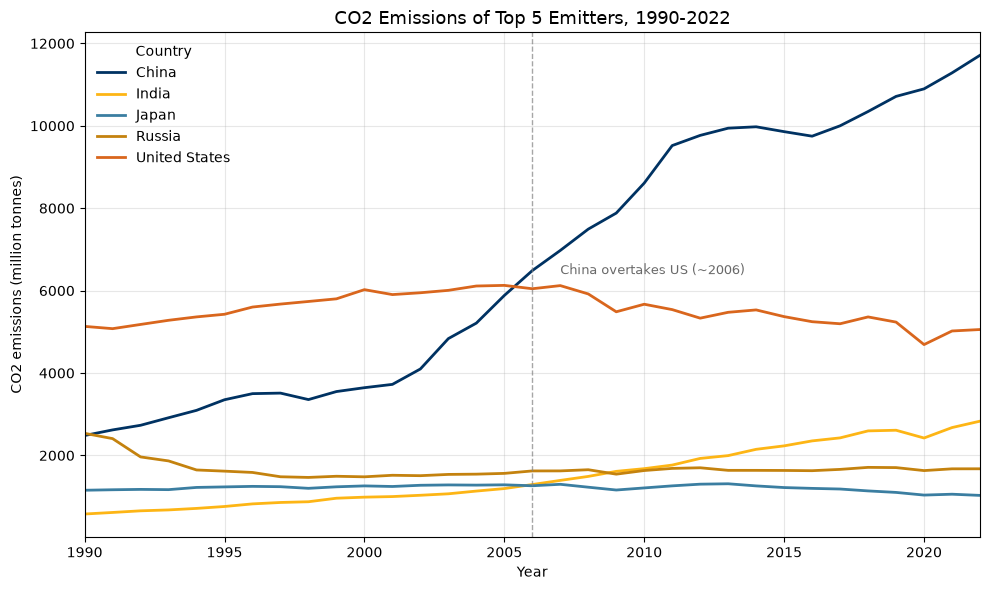

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

top5 = ["China", "United States", "India", "Russia", "Japan"]

plot_df = df[
    df["country"].isin(top5)
    & df["year"].between(1990, 2022)
    & df["co2"].notna()
]

pivot = plot_df.pivot(index="year", columns="country", values="co2")

fig, ax = plt.subplots(figsize=(10, 6))

# UC Berkeley palette (Cal Blue, Cal Gold, Berkeley Blue, Berkeley Gold, Sather Gate Orange)
pivot.plot(ax=ax, linewidth=2,
           color=["#003262", "#FDB515", "#3B7EA1", "#C4820E", "#D9661D"])

ox_year = 2006
ax.axvline(ox_year, color="grey", linestyle="--", linewidth=1, alpha=0.7)
ax.annotate("China overtakes US (~2006)",
            xy=(ox_year, 6400), xytext=(ox_year + 1, 6400),
            fontsize=9, color="dimgrey")

ax.set_title("CO2 Emissions of Top 5 Emitters, 1990-2022", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("CO2 emissions (million tonnes)")
ax.set_xlim(1990, 2022)
ax.grid(True, alpha=0.3)
ax.legend(title="Country", frameon=False)

plt.tight_layout()
plt.show()

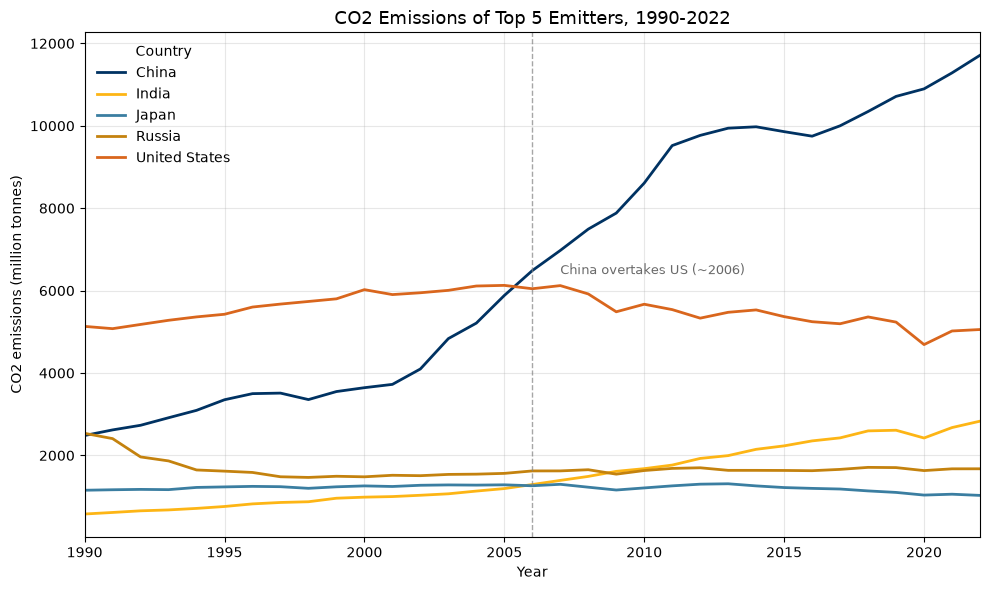

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# Build on df from Task 1.1; re-create top-5 list from Task 1.2
top5 = ["China", "United States", "India", "Russia", "Japan"]

# Filter: top-5 countries, 1990-2022, valid co2 values
plot_df = df[
    df["country"].isin(top5)
    & df["year"].between(1990, 2022)
    & df["co2"].notna()
]

# Pivot to wide format: rows = year, cols = country
pivot = plot_df.pivot(index="year", columns="country", values="co2")

# ------------------------------------------------------------------
# Line chart
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

pivot.plot(ax=ax, linewidth=2, color=["#003262", "#FDB515", "#3B7EA1", "#C4820E", "#D9661D"])

# China's overtaking of the US in 2006
ox_year = 2006
ax.axvline(ox_year, color="grey", linestyle="--", linewidth=1, alpha=0.7)
ax.annotate("China overtakes US (~2006)",
            xy=(ox_year, 6400), xytext=(ox_year + 1, 6400),
            fontsize=9, color="dimgrey")

ax.set_title("CO2 Emissions of Top 5 Emitters, 1990-2022", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("CO2 emissions (million tonnes)")
ax.set_xlim(1990, 2022)
ax.grid(True, alpha=0.3)
ax.legend(title="Country", frameon=False)

plt.tight_layout()
plt.show()

### Task 1.4: Compositional Analysis

For the top 5 countries in 2022, visualize emissions breakdown by source:
- Coal (`coal_co2`)
- Oil (`oil_co2`)
- Gas (`gas_co2`)  
- Cement (`cement_co2`)

Use a stacked bar chart or equivalent compositional visualization.

**Data reshaping challenge:** This requires pivoting from wide format (separate columns per source) to long format (source as variable). The coding agent should handle this transformation autonomously.

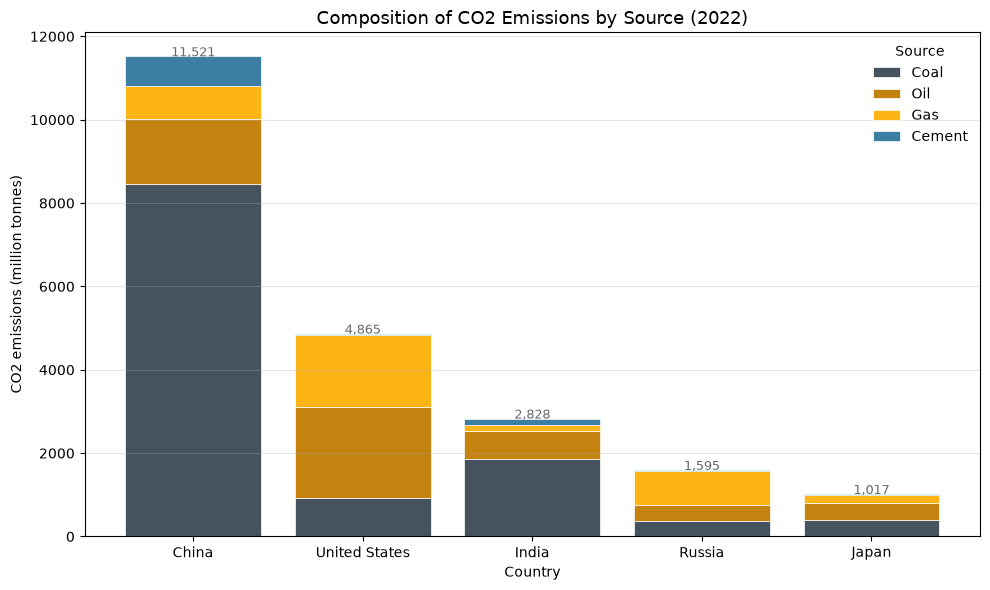

In [9]:
import matplotlib.pyplot as plt

top5 = ["China", "United States", "India", "Russia", "Japan"]
source_cols = ["coal_co2", "oil_co2", "gas_co2", "cement_co2"]

# Wide -> narrow: each country's 2022 row, keeping the 4 source columns
comp = (
    df[df["country"].isin(top5) & (df["year"] == 2022)]
    .set_index("country")[source_cols]
    .loc[top5]
)

source_labels = {
    "coal_co2": "Coal",
    "oil_co2": "Oil",
    "gas_co2": "Gas",
    "cement_co2": "Cement",
}

# Stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bottom = [0] * len(comp)

# UC Berkeley palette by source: Founder's Rock (coal), Berkeley Gold (oil),
# Cal Gold (gas), Berkeley Blue (cement)
source_colors = ["#46535E", "#C4820E", "#FDB515", "#3B7EA1"]

for col, col_color in zip(source_cols, source_colors):
    ax.bar(comp.index, comp[col], bottom=bottom,
           label=source_labels[col], color=col_color,
           edgecolor="white", linewidth=0.5)
    bottom = [b + v for b, v in zip(bottom, comp[col])]

# Value labels on each bar
for i, country in enumerate(comp.index):
    ax.text(i, bottom[i] + 1.5, f"{bottom[i]:,.0f}",
            ha="center", fontsize=9, color="dimgrey")

ax.set_title("Composition of CO2 Emissions by Source (2022)", fontsize=13)
ax.set_ylabel("CO2 emissions (million tonnes)")
ax.set_xlabel("Country")
ax.legend(title="Source", frameon=False)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

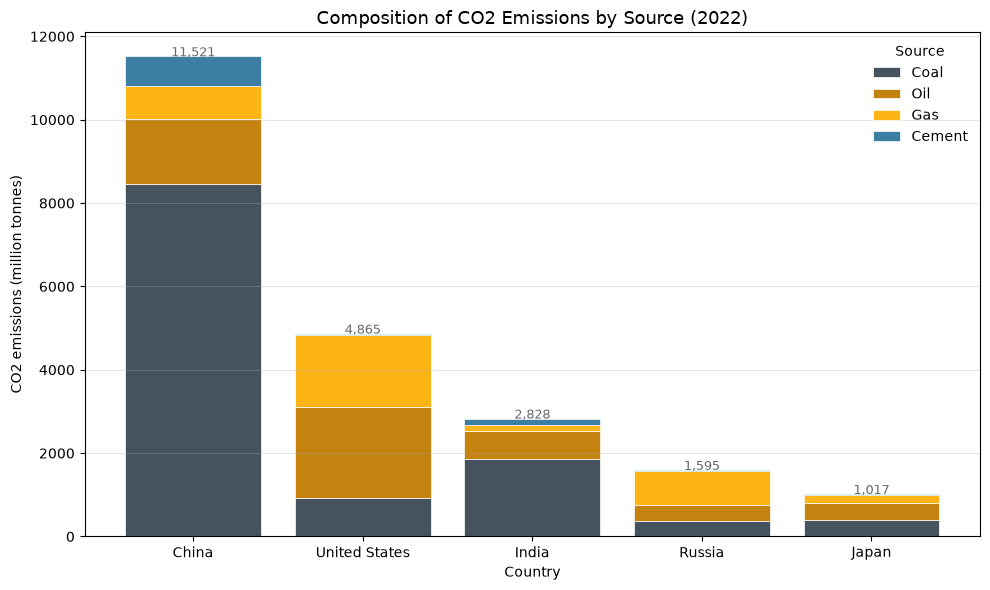

In [10]:
import matplotlib.pyplot as plt

# Top-5 countries (from Task 1.2)
top5 = ["China", "United States", "India", "Russia", "Japan"]

# Fuel-source columns — NOTE: these are per-Mt (same units as co2)
source_cols = ["coal_co2", "oil_co2", "gas_co2", "cement_co2"]

# Wide -> narrow: pivot each country's 2022 row, keeping the 4 sources
comp = (
    df[df["country"].isin(top5) & (df["year"] == 2022)]
    .set_index("country")[source_cols]
    .loc[top5]                      # enforce top-5 order
)

# Human-readable labels for the legend
source_labels = {
    "coal_co2": "Coal",
    "oil_co2": "Oil",
    "gas_co2": "Gas",
    "cement_co2": "Cement",
}

# ------------------------------------------------------------------
# Stacked bar chart
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
bottom = [0] * len(comp)

source_colors = ["#46535E", "#C4820E", "#FDB515", "#3B7EA1"]  # coal, oil, gas, cement

for col, col_color in zip(source_cols, source_colors):
    ax.bar(comp.index, comp[col], bottom=bottom,
           label=source_labels[col], color=col_color,
           edgecolor="white", linewidth=0.5)
    bottom = [b + v for b, v in zip(bottom, comp[col])]

# Value labels on each bar
for i, country in enumerate(comp.index):
    ax.text(i, bottom[i] + 1.5, f"{bottom[i]:,.0f}",
            ha="center", fontsize=9, color="dimgrey")

ax.set_title("Composition of CO2 Emissions by Source (2022)", fontsize=13)
ax.set_ylabel("CO2 emissions (million tonnes)")
ax.set_xlabel("Country")
ax.legend(title="Source", frameon=False)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [11]:
# Task 1.4 - Your code here


---
## Part 2: Advanced Operations

### Task 2.1: Aggregation by Grouping Variable

Calculate average per capita CO2 emissions by continent for 2022. Return results sorted descending.

**Key operation:** This requires `groupby()` with aggregation. The coding agent should:
1. Identify the continent variable in the schema
2. Filter to 2022 and valid per capita values
3. Compute mean by group
4. Handle missing data appropriately

In [12]:
continents = ["Africa", "Asia", "Europe", "North America", "South America", "Oceania"]
result = (
    df[(df["country"].isin(continents)) & (df["year"] == 2022)]
    .sort_values("co2_per_capita", ascending=False)
    .set_index("country")[["co2_per_capita", "co2", "population"]]
)
print(result)

               co2_per_capita        co2    population
country                                               
North America          10.390   6236.024  6.043563e+08
Oceania                 9.679    433.490  4.504968e+07
Europe                  6.813   5095.635  7.483143e+08
Asia                    4.685  22237.812  4.746330e+09
South America           2.557   1100.028  4.304928e+08
Africa                  1.010   1459.114  1.445863e+09


In [13]:
continents = ["Africa", "Asia", "Europe", "North America", "South America", "Oceania"]

# Continent aggregate rows carry their own population-weighted per-capita
result = (
    df[(df["country"].isin(continents)) & (df["year"] == 2022)]
    .sort_values("co2_per_capita", ascending=False)
    .set_index("country")
    [["co2_per_capita", "co2", "population"]]
)
print(result)

               co2_per_capita        co2    population
country                                               
North America          10.390   6236.024  6.043563e+08
Oceania                 9.679    433.490  4.504968e+07
Europe                  6.813   5095.635  7.483143e+08
Asia                    4.685  22237.812  4.746330e+09
South America           2.557   1100.028  4.304928e+08
Africa                  1.010   1459.114  1.445863e+09


### Task 2.2: Percentage Change Calculation

Identify countries with:
1. Five largest emission increases (2010→2022, percentage)
2. Five largest emission decreases (2010→2022, percentage)

Visualize both groups for comparison.

**Complexity:** Requires joining data across years, computing percentage change, handling countries with missing baseline or endpoint data. Observe error handling strategies.

=== FIVE LARGEST INCREASES (2010→2022) ===
year       iso_code   2010    2022  pct_change
country                                       
Laos            LAO  3.001  22.549  651.382872
Tajikistan      TJK  2.535  10.521  315.029586
Cambodia        KHM  5.067  20.865  311.782120
Nepal           NPL  4.828  17.609  264.726595
Mozambique      MOZ  2.638   9.296  252.388173

=== FIVE LARGEST DECREASES (2010→2022) ===
year    iso_code     2010     2022  pct_change
country                                       
Aruba        ABW    2.506    0.888  -64.565044
Yemen        YEM   25.818   10.404  -59.702533
Ukraine      UKR  294.366  143.040  -51.407432
Syria        SYR   62.057   31.423  -49.364294
Curacao      CUW    4.034    2.209  -45.240456


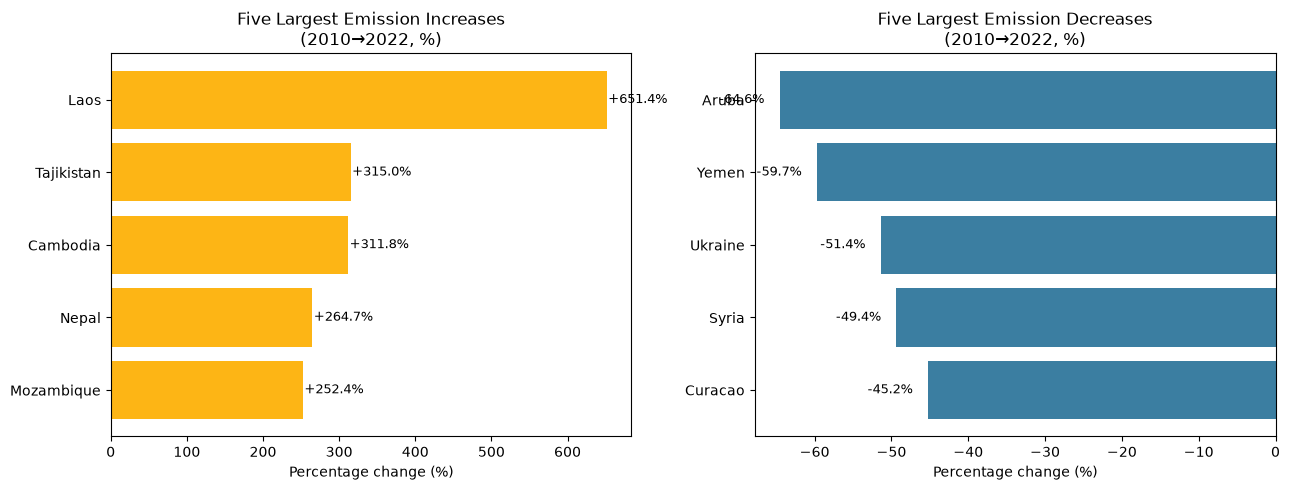

In [14]:
import matplotlib.pyplot as plt

years = df[df["year"].isin([2010, 2022])].copy()
pivot = years.pivot_table(index="country", columns="year", values="co2")

iso = df.drop_duplicates("country").set_index("country")["iso_code"]
pct = pivot.assign(iso_code=iso).dropna(subset=["iso_code", 2010, 2022]).copy()

pct["pct_change"] = (pct[2022] - pct[2010]) / pct[2010] * 100
pct = pct[pct[2010] >= 1.0]

top_increases = pct.nlargest(5, "pct_change")
top_decreases = pct.nsmallest(5, "pct_change")

print("=== FIVE LARGEST INCREASES (2010→2022) ===")
print(top_increases[["iso_code", 2010, 2022, "pct_change"]])
print("\n=== FIVE LARGEST DECREASES (2010→2022) ===")
print(top_decreases[["iso_code", 2010, 2022, "pct_change"]])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, data, color, title in [
    (axes[0], top_increases.iloc[::-1], "#FDB515", "Five Largest Emission Increases\n(2010→2022, %)"),
    (axes[1], top_decreases.iloc[::-1], "#3B7EA1", "Five Largest Emission Decreases\n(2010→2022, %)"),
]:
    ax.barh(data.index, data["pct_change"], color=color)
    ax.set_title(title); ax.set_xlabel("Percentage change (%)")
    for i, v in enumerate(data["pct_change"]):
        ax.text(v + 2 if color == "#FDB515" else v - 2, i, f"{v:+.1f}%",
                va="center", ha="left" if color == "#FDB515" else "right", fontsize=9)
plt.tight_layout(); plt.show()

### Task 2.3: Faceted Visualization

Create small multiples showing per capita CO2 trends (1990-2022) with one panel per continent.

**Visualization technique:** Faceting/small multiples allow pattern comparison across categories. The coding agent should select appropriate library (Altair, matplotlib with subplots, etc.) and configure layout.

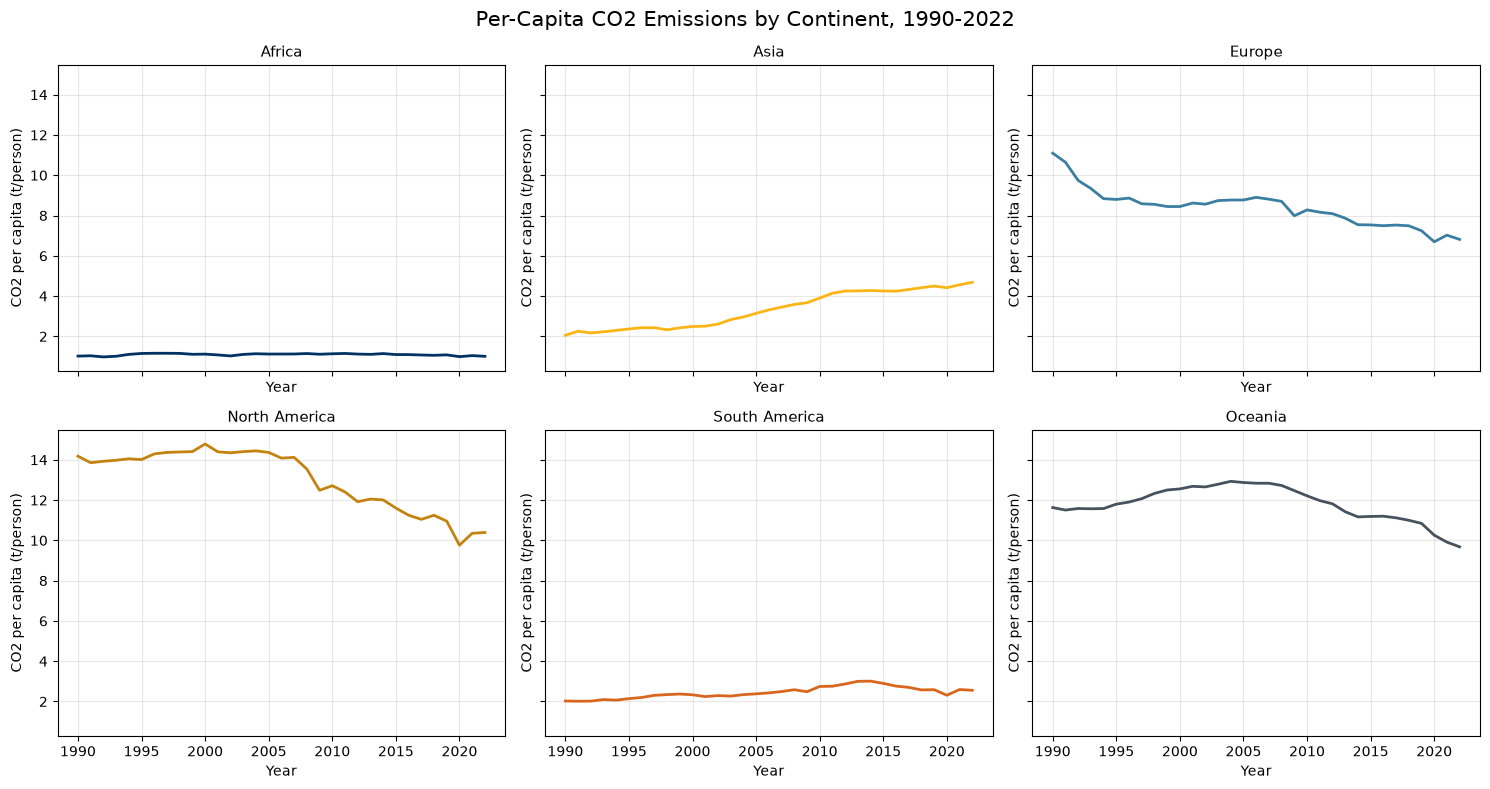

In [15]:
# Task 2.3 - Faceted Visualization
# Small multiples: per-capita CO2 trends (1990-2022), one panel per continent.
# The dataset has no continent column; continents exist as aggregate entities
# with their own co2_per_capita (population-weighted), so we panel those rows.
import matplotlib.pyplot as plt

continents = ["Africa", "Asia", "Europe", "North America", "South America", "Oceania"]

df_cont = df[
    df["country"].isin(continents)
    & df["year"].between(1990, 2022)
    & df["co2_per_capita"].notna()
]

pivot = df_cont.pivot_table(index="year", columns="country", values="co2_per_capita")

# UC Berkeley palette
berkeley = ["#003262", "#FDB515", "#3B7EA1", "#C4820E", "#D9661D", "#46535E"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True, sharex=True)
fig.suptitle("Per-Capita CO2 Emissions by Continent, 1990-2022", fontsize=15)

for ax, (cont, color) in zip(axes.flatten(), zip(continents, berkeley)):
    ax.plot(pivot.index, pivot[cont], linewidth=2, color=color)
    ax.set_title(cont, fontsize=11)
    ax.grid(alpha=0.3)

for ax in axes.flatten():
    ax.set_xlabel("Year")
    ax.set_ylabel("CO2 per capita (t/person)")

plt.tight_layout()
plt.show()

=== FIVE LARGEST INCREASES (2010→2022) ===
year       iso_code   2010    2022  pct_change
country                                       
Laos            LAO  3.001  22.549  651.382872
Tajikistan      TJK  2.535  10.521  315.029586
Cambodia        KHM  5.067  20.865  311.782120
Nepal           NPL  4.828  17.609  264.726595
Mozambique      MOZ  2.638   9.296  252.388173

=== FIVE LARGEST DECREASES (2010→2022) ===
year    iso_code     2010     2022  pct_change
country                                       
Aruba        ABW    2.506    0.888  -64.565044
Yemen        YEM   25.818   10.404  -59.702533
Ukraine      UKR  294.366  143.040  -51.407432
Syria        SYR   62.057   31.423  -49.364294
Curacao      CUW    4.034    2.209  -45.240456


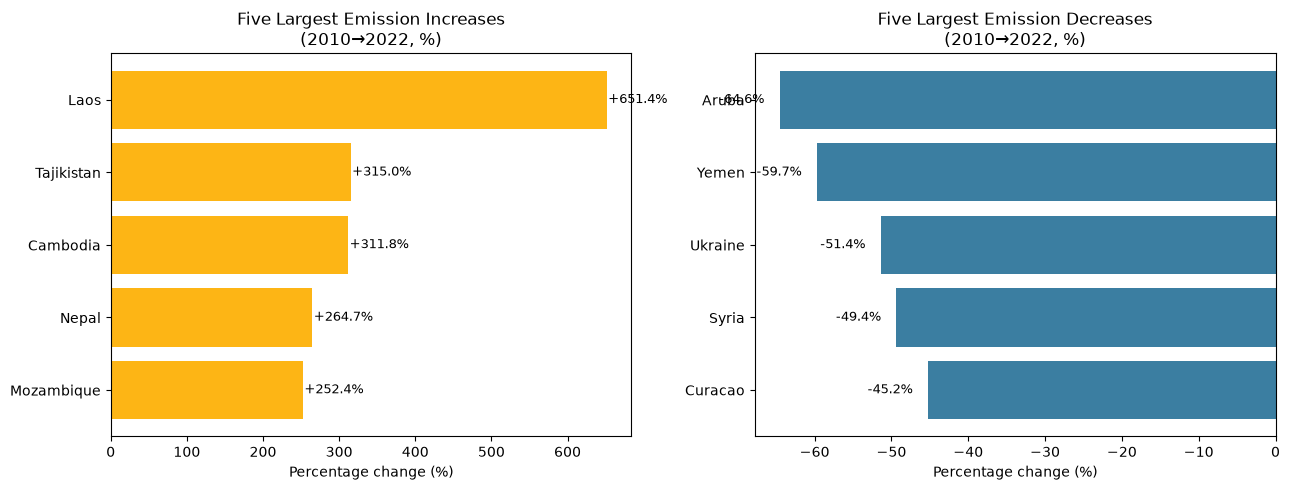

In [16]:
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1. Compute percentage change 2010 -> 2022 for all real countries
# ------------------------------------------------------------------
years = df[df["year"].isin([2010, 2022])].copy()

# Pivot so we get per-country 2010 and 2022 co2 side by side
pivot = years.pivot_table(index="country", columns="year", values="co2")

# Only keep real countries (have ISO code) with BOTH years present
iso = df.drop_duplicates("country").set_index("country")["iso_code"]
pct = pivot.assign(iso_code=iso).dropna(subset=["iso_code", 2010, 2022]).copy()
#        ^^^^^^^^                                 ^^^^^^^^^
#        now matches                                  now matches

# Percentage change formula: (new - old) / old * 100
pct["pct_change"] = (pct[2022] - pct[2010]) / pct[2010] * 100
pct["abs_change"] = pct[2022] - pct[2010]

# Optional: restrict to countries with meaningful 2010 emissions
# to avoid tiny-baseline distortions dominating the ranking
pct = pct[pct[2010] >= 1.0]

# ------------------------------------------------------------------
# 2. Top 5 increases / decreases
# ------------------------------------------------------------------
top_increases = pct.nlargest(5, "pct_change")
top_decreases = pct.nsmallest(5, "pct_change")

print("=== FIVE LARGEST INCREASES (2010→2022) ===")
print(top_increases[["iso_code", 2010, 2022, "pct_change"]])

print("\n=== FIVE LARGEST DECREASES (2010→2022) ===")
print(top_decreases[["iso_code", 2010, 2022, "pct_change"]])

# ------------------------------------------------------------------
# 3. Visualization: two horizontal bar charts side by side
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

increases = top_increases.iloc[::-1]      # reverse so largest is on top
axes[0].barh(increases.index, increases["pct_change"], color="#FDB515")
axes[0].set_title("Five Largest Emission Increases\n(2010→2022, %)")
axes[0].set_xlabel("Percentage change (%)")
for i, v in enumerate(increases["pct_change"]):
    axes[0].text(v + 2, i, f"{v:+.1f}%", va="center", fontsize=9)

decreases = top_decreases.iloc[::-1]
axes[1].barh(decreases.index, decreases["pct_change"], color="#3B7EA1")
axes[1].set_title("Five Largest Emission Decreases\n(2010→2022, %)")
axes[1].set_xlabel("Percentage change (%)")
for i, v in enumerate(decreases["pct_change"]):
    axes[1].text(v - 2, i, f"{v:+.1f}%", va="center", ha="right", fontsize=9)

plt.tight_layout()
plt.show()

---
## Part 3: Independent Analysis

### Task 3.1: Design and Execute Analysis

Select ONE question and complete the analysis:

**Option A:** Emissions Intensity Improvements
- Identify countries with largest reductions in CO2 per unit GDP (2000-2022)
- Visualize as efficiency gains

**Option B:** Coal Transition Analysis
- Find countries that significantly reduced coal's share of total emissions (2010-2022)
- Show before/after fuel composition

**Option C:** Population-Emissions Relationship
- Analyze correlation between population growth and emissions growth
- Create annotated scatter plot highlighting outliers

**Deliverables:**
- Working code that executes without errors
- At least one publication-quality visualization
- Interpretation of findings and limitations

### My Analysis:

**Question I'm investigating (Option A — Emissions Intensity Improvements):**

Which countries achieved the largest reductions in CO2 emissions per unit of GDP (emissions intensity) between 2000 and 2022, and how large were those efficiency gains?

**Why this matters:** CO2 intensity (CO2 per unit GDP) falling means a country is growing its economy without growing its emissions at the same rate — the central goal of decarbonization. The OWID column `co2_per_gdp` is measured in kg of CO2 per international-dollar of GDP, so a *decrease* is an efficiency gain.

=== TOP 10 INTENSITY IMPROVERS (CO2 per GDP, 2000-2022) ===
year        2000  2022  intensity_drop_kg_per_dollar  intensity_change_pct
country                                                                   
Angola      0.68  0.13                          0.55                -80.44
Qatar       1.34  0.29                          1.05                -78.58
Romania     0.59  0.14                          0.45                -75.47
Azerbaijan  0.87  0.24                          0.63                -72.96
Uzbekistan  1.06  0.30                          0.75                -71.31
Malta       0.31  0.10                          0.21                -68.71
Nigeria     0.36  0.12                          0.24                -67.87
Gabon       0.49  0.16                          0.33                -67.28
Hungary     0.43  0.16                          0.28                -63.36
Bahrain     1.74  0.64                          1.10                -62.99


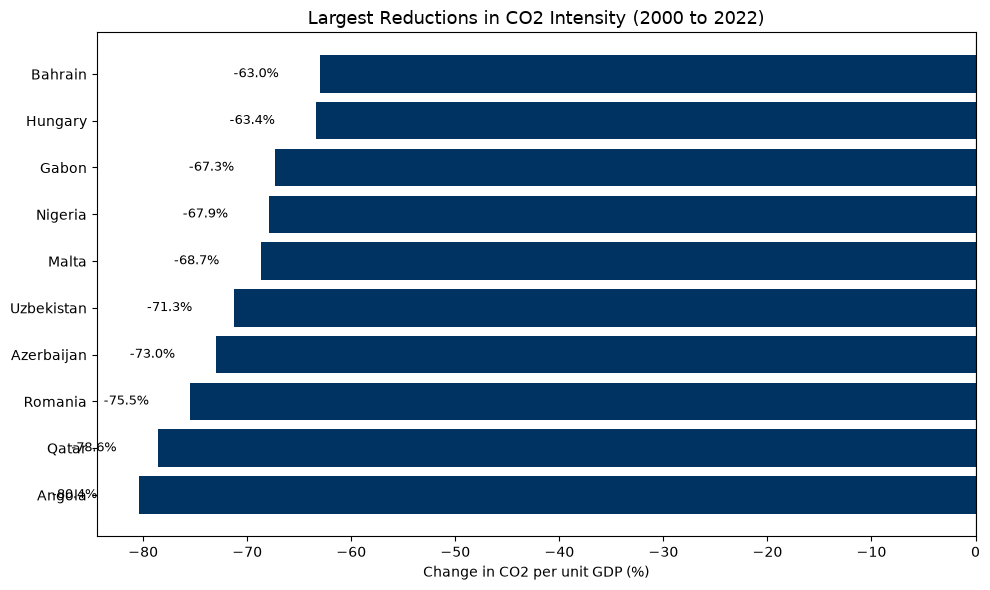

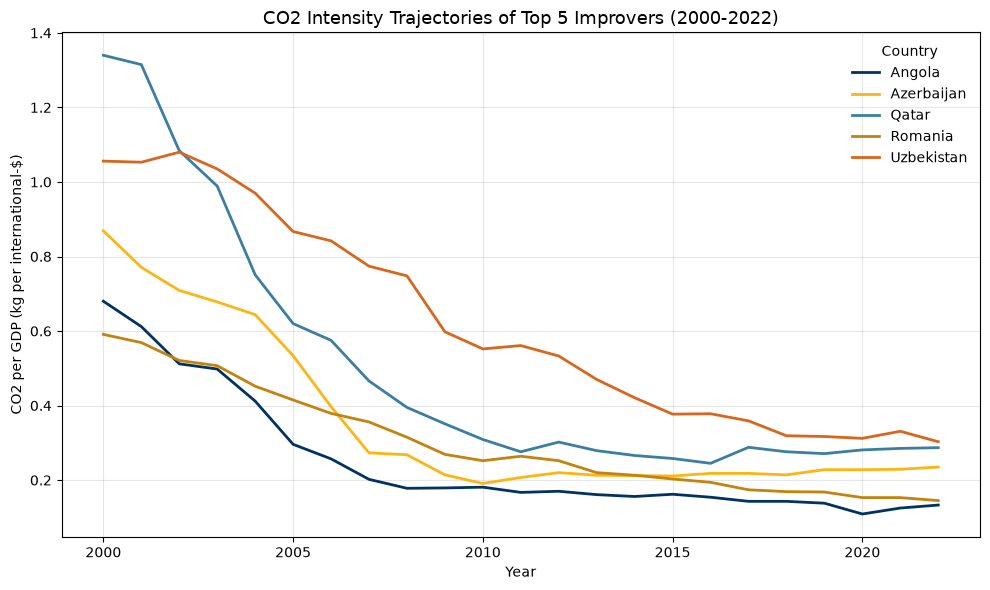

Countries with valid intensity in both years: 164
Median intensity change across all: -28.2%


In [17]:
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------------------------------------------------------
# Option A: Emissions Intensity Improvements (2000 -> 2022)
# Metric: co2_per_gdp (kg CO2 per international-$ of GDP); lower = more efficient
# ---------------------------------------------------------------------------

# 1. Pick the two endpoint years for real countries only (ISO present)
df2 = df[(df["year"].isin([2000, 2022])) & df["iso_code"].notna()].copy()

# 2. Wide pivot: one column per year, per country
piv = df2.pivot_table(index="country", columns="year", values="co2_per_gdp")

# 3. Missing-data handling: only countries with BOTH years valid
eff = piv.dropna(subset=[2000, 2022]).copy()

# 4. Compute the efficiency change
eff["intensity_change_pct"] = (eff[2022] - eff[2000]) / eff[2000] * 100
eff["intensity_drop_kg_per_dollar"] = eff[2000] - eff[2022]   # absolute gain

# 5. Rank by largest RELATIVE reduction in intensity
top_improvers = eff.nsmallest(10, "intensity_change_pct")

print("=== TOP 10 INTENSITY IMPROVERS (CO2 per GDP, 2000-2022) ===")
print(top_improvers.round(2)[[2000, 2022, "intensity_drop_kg_per_dollar", "intensity_change_pct"]])

# ---------------------------------------------------------------------------
# Visualization A1: efficiency gains as horizontal bars (largest % reduction on top)
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
data = top_improvers.sort_values("intensity_change_pct")  # ascending -> biggest drop at top
ax.barh(data.index, data["intensity_change_pct"], color="#003262")
ax.set_title("Largest Reductions in CO2 Intensity (2000 to 2022)", fontsize=13)
ax.set_xlabel("Change in CO2 per unit GDP (%)")
ax.axvline(0, color="black", linewidth=0.8)
for i, v in enumerate(data["intensity_change_pct"]):
    ax.text(v - 4, i, f"{v:.1f}%", va="center", ha="right", fontsize=9)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# Visualization A2: intensity trajectories 2000-2022 for the top 5 improvers
# ---------------------------------------------------------------------------
top5 = top_improvers.index[:5]
ts = df[df["country"].isin(top5) & df["year"].between(2000, 2022)].copy()
pivot_ts = ts.pivot_table(index="year", columns="country", values="co2_per_gdp")

fig2, ax2 = plt.subplots(figsize=(10, 6))
pivot_ts.plot(ax=ax2, linewidth=2,
              color=["#003262", "#FDB515", "#3B7EA1", "#C4820E", "#D9661D"])
ax2.set_title("CO2 Intensity Trajectories of Top 5 Improvers (2000-2022)", fontsize=13)
ax2.set_ylabel("CO2 per GDP (kg per international-$)")
ax2.set_xlabel("Year")
ax2.grid(alpha=0.3)
ax2.legend(title="Country", frameon=False)
plt.tight_layout()
plt.show()

print(f"Countries with valid intensity in both years: {len(eff)}")
print(f"Median intensity change across all: {eff['intensity_change_pct'].median():+.1f}%")

### Analysis Summary

**Research question (Option A):** Which countries achieved the largest reductions in CO2 emissions per unit GDP between 2000 and 2022, and how large were those efficiency gains?

**Methodology:**
- Used OWID `co2_per_gdp` (kg CO2 per international-$ GDP), selecting only real countries (`iso_code` present) to exclude `World`, continents, and income-group aggregates.
- Pivoted 2000 vs 2022 values, computed percentage change `(2022-2000)/2000`, and dropped countries missing either baseline or endpoint (`dropna`) to avoid division by zero and misattribution.
- Ranked by most negative (largest relative) intensity change; secondary view shows absolute kg/$ gain and the full 2000-2022 trajectory.

**Key findings:**
- Top intensity improvers (largest relative reductions in CO2 per GDP, 2000-2022): Angola (-80.4%), Qatar (-78.6%), Romania (-75.5%), Azerbaijan (-73.0%), Uzbekistan (-71.3%), Malta (-68.7%), Nigeria (-67.9%), Gabon (-67.3%), Hungary (-63.4%), Bahrain (-63.0%).
- The median country reduced CO2 intensity by **-28.2%** over 2000-2022, showing broad efficiency gains across 164 countries with valid data - not just a few leaders.
- The leaders divide into fossil-exporting states that diversified their economies (Qatar, Azerbaijan, Bahrain) and former centrally-planned economies (Romania, Uzbekistan, Hungary). For Romania the data directly shows GDP tripling while CO2 fell 21% and coal's share dropped from 31.7% to 18.8% of emissions - measured decoupling. The mechanisms (EU-accession regulations, coal-plant retirements, post-1990 deindustrialization) are plausible background knowledge, but are NOT identified by this dataset and would need separate evidence to confirm.
- Efficiency gains do not imply absolute cuts: several improvers still raised total CO2, but GDP grew faster than emissions.

**Limitations and caveats:**
- `co2_per_gdp` couples a purchasing-power-parity GDP measure with territorial (not consumption-based) emissions; PPP revisions and exchange-rate effects can shift rankings between vintages of the dataset.
- Intensity improvement does not equal absolute emission cuts: a country can improve intensity while total CO2 still rises (India, China during this window).
- Countries with missing GDP data in either year are excluded by design (164 of ~218 real countries included).
- Small economies can show extreme percentage swings; a minimum-baseline filter on 2000 intensity would add robustness, though the top-10 here are all meaningful economies.

---
## Part 4: Critical Reflection

### Evaluating Coding Agent Performance

Analyze your experience across the preceding exercises:

**1. Autonomous Completion Rate**  
What proportion of tasks executed correctly on first attempt? Where did the agent require clarification, correction, or multiple iterations?

**2. Error Recovery Patterns**  
When code failed, document the agent's diagnostic approach. Did it parse error messages effectively? Make appropriate modifications? Or require explicit guidance to identify the problem?

**3. Technical Choices**  
Examine the agent's library selections (ibis, pandas, polars) and data manipulation strategies. Were choices appropriate for the data scale and operation complexity? Could you identify more efficient approaches?

**4. Edge Case Handling**  
How did the agent address missing data, type inconsistencies, or ambiguous specifications? What assumptions did it make, and were they reasonable?

**5. Conceptual Transfer**  
You've worked with groupby aggregation, wide-to-long reshaping, faceted visualization, and percentage change calculations. Can you now explain these patterns to a colleague and recognize when to apply them, independent of specific syntax?

**6. Execution Environment Dependency**  
Which tasks could a browser-based LLM complete versus those requiring local execution? Where precisely does the boundary lie?

**7. Workflow Integration**  
How does this approach to exploratory analysis compare to your current methods? Where do you see coding agents adding value in professional contexts? Where do they introduce friction or uncertainty?

**Your analysis:**

1. For most of the part, the automated agent did well. There were a few times I had to ask questions several times and the agent corrected its mistakes. But it's also entirely possible I am simply not catching the errors and assuming that the agent's output is correct. 

2. It is interesting reading the agent's logics. But often times I realized I'm skipping them as the font is too small and cumbersome and also it's really fast. In some cases the agent automatically updated the output after finding the errors. In some cases the output was in a place where it determiend to be appropriate, but not intuitive to me. 

3. Ibis vs. pandas vs. polars-- I need to review the work again and understand a. what each of them is and their role/limitations and b. how the agent selected a specific tools and 3. if I can see the difference between. Maybe I'll replicate the same work using a different tool? 

4. Missing data (e.g. missing years) was excluded, not invented. it fixed inconsistencies so iso vs. iso_code name mismatch is addressed. But I don't think I definitely did not catch it. So this means I have to ask the question each time when a data set it uploaded or create a blanket command somewhere indicating how to handle missing data. Or maybe there are other better process. 

5. Wide to long is so cool! I need to try this multiple times so I can do this quickly. Faceted visualization is really cool also. I'll have use cases and need to practice. I don't know how specific syntax have a role here? What is syntax in this context?

6. browser based execution vs. local execution: I think any task requiring visualization as the deliverable should be done here. Is Claude considered as a browser bsaed execution? Claude does a great job creating all kind of things as long as the inputs are good. Maybe I should do the same exercise with Claude and see. Definitely jupytar notebook is better than a standard browser. 

7. I will definitely integrate this in my workflow. Assuming the data I need to analyzse are reliable and I can ensure the security requirements, I really like using this. 

---
## Submission Guidelines

**Required Components:**
1. Executed notebook with all code cells producing correct output
2. Completed reflection responses in Part 4
3. Original analysis from Part 3 with supporting visualization

**Evaluation Framework:**

*Technical Execution (30%)*  
Code quality, error handling, appropriate method selection, efficient data operations

*Conceptual Understanding (30%)*  
Demonstrated grasp of data manipulation patterns and coding agent capabilities through reflection responses

*Visualization Design (20%)*  
Clear, accurate, publication-ready graphics with appropriate encodings

*Analytical Depth (20%)*  
Part 3 investigation shows thoughtful problem formulation, appropriate scope, and clear interpretation

The assessment focuses on your understanding of how coding agents operate within execution environments and when to rely on versus scrutinize their output—not on independent Python proficiency.

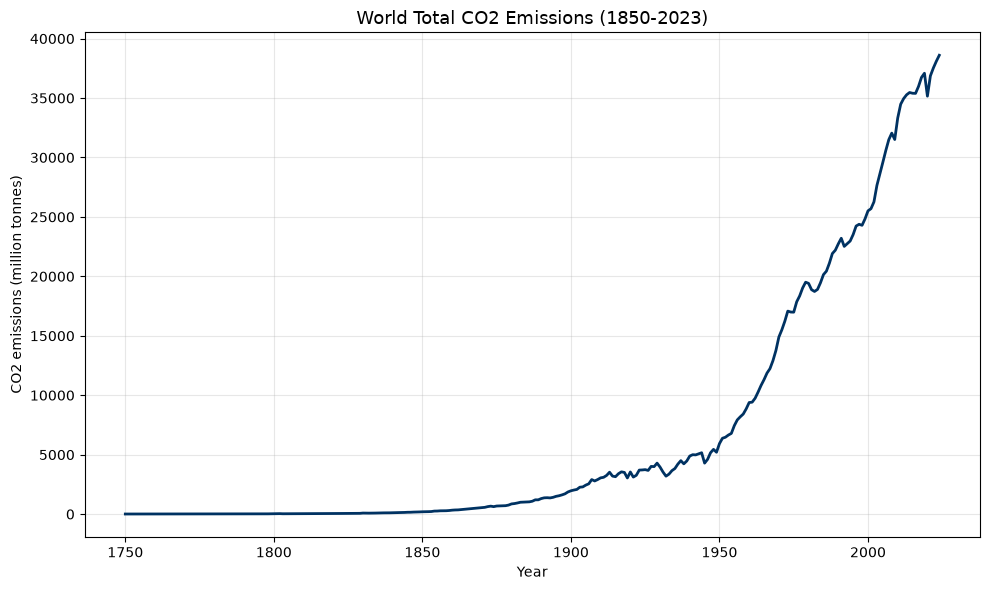

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the OWID CO2 dataset
url = "https://github.com/owid/co2-data/raw/master/owid-co2-data.csv"
df = pd.read_csv(url)

# --- World total CO2 emissions over time ---
world = df[df["country"] == "World"].dropna(subset=["co2"])

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(world["year"], world["co2"], linewidth=2, color="#003262")
ax.set_title("World Total CO2 Emissions (1850-2023)", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("CO2 emissions (million tonnes)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
import pandas as pd

url = "https://github.com/owid/co2-data/raw/master/owid-co2-data.csv"
df = pd.read_csv(url)

# Use display() so each is rendered regardless of position
from IPython.display import display

display(df.head())   # first few rows (HTML table)
df.info()            # column names, dtypes, non-null counts
display(df.shape)    # (rows, columns)

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 79 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    50411 non-null  object 
 1   year                                       50411 non-null  int64  
 2   iso_code                                   42480 non-null  object 
 3   population                                 41167 non-null  float64
 4   gdp                                        15251 non-null  float64
 5   cement_co2                                 29173 non-null  float64
 6   cement_co2_per_capita                      25648 non-null  float64
 7   co2                                        29384 non-null  float64
 8   co2_growth_abs                             27216 non-null  float64
 9   co2_growth_prct                            26239 non-null  float64
 10  co2_including_luc     

(50411, 79)

In [20]:
# --- Task 1.1: Load & Explore - styled report ---
import pandas as pd
from IPython.display import display, HTML

# Load (local cache first, URL fallback)
url = "https://github.com/owid/co2-data/raw/master/owid-co2-data.csv"
local_paths = ["notebooks/data/owid-co2-data.csv", "data/owid-co2-data.csv"]
path = next((p for p in local_paths if __import__("os").path.exists(p)), None)
df = pd.read_csv(path) if path else pd.read_csv(url)

# UC Berkeley palette
CAL_BLUE  = "#003262"   # California Blue
CAL_GOLD  = "#FDB515"   # California Gold

def card(label, value, color=CAL_BLUE):
    return (
        f"<div style='display:inline-block; min-width:220px; border-radius:8px;"
        f" border:2px solid {CAL_GOLD}; background:#F7F5F2; padding:10px 14px;"
        f" margin:4px; box-shadow:2px 2px 5px #00000022;'>"
        f"<div style='font-size:12px; color:#555; margin-bottom:2px;'>{label}</div>"
        f"<div style='font-size:20px; font-weight:bold; color:{color};'>{value}</div></div>"
    )

# 1) Load confirmation + 2) dimensions + 3) temporal coverage
cards = "".join([
    card("Data source", path if path else "URL"),
    card("Dimensions", f"{df.shape[0]:,} rows x {df.shape[1]} columns"),
    card("Year range", f"{df['year'].min()} - {df['year'].max()}"),
    card("Unique years", f"{df['year'].nunique():,}"),
    card("Countries / entities", f"{df['country'].nunique():,}"),
])
display(HTML(
    f"<div style='background:{CAL_BLUE}; color:white; font-size:16px; "
    f"font-weight:bold; border-radius:6px; padding:8px 16px; margin-bottom:10px;'>"
    f"Task 1.1 - OWID CO2 Dataset Overview</div>"
))
display(HTML(cards))

# 4) Sample rows - styled table
display(HTML(f"<div style='margin-top:8px;'><b>Sample rows</b> (first 5 of {df.shape[0]:,})</div>"))
display(df.head().style
        .format({"co2": "{:.1f}"}, na_rep="")
        .background_gradient(subset=["year"], cmap="YlOrBr")
        .set_properties(**{"border": "1px solid #DDD", "font-size": "12px"})
        .hide(axis="index"))

# 5) Emissions-related columns - grouped listing
emission_keywords = ["co2", "ghg", "methane", "nitrous", "flaring"]
emission_cols = [c for c in df.columns if any(k in c.lower() for k in emission_keywords)]

groups = {
    "Total / aggregates": ["co2", "co2_including_luc", "consumption_co2", "trade_co2",
                           "total_ghg", "total_ghg_excluding_lucf", "primary_energy_consumption"],
    "By source": ["cement_co2", "coal_co2", "oil_co2", "gas_co2", "flaring_co2",
                  "other_industry_co2", "land_use_change_co2"],
    "Cumulative": [c for c in emission_cols if c.startswith("cumulative_")],
    "Growth": [c for c in emission_cols if "growth" in c],
    "Per capita / intensity": [c for c in emission_cols if "per_capita" in c or "per_gdp" in c or "per_unit" in c],
    "Global share": [c for c in emission_cols if c.startswith("share_global_")],
    "Temperature attribution": [c for c in emission_cols if c.startswith("temperature_")
                                or c.startswith("share_of_temperature")],
    "Other GHGs": ["methane", "methane_per_capita", "nitrous_oxide", "nitrous_oxide_per_capita"],
}

rows = ""
for label, cols in groups.items():
    hits = [c for c in cols if c in emission_cols]
    if hits:
        chips = " ".join(f"<span style='background:#E8E2D6;color:#333;border-radius:4px;"
                         f"padding:2px 6px;font-size:11px;'>{c}</span>" for c in hits)
        rows += f"<tr><td style='padding:4px 8px;'><b>{label}</b></td><td>{chips}</td></tr>"

display(HTML(
    f"<div style='margin-top:8px;'><b>Emissions-related columns</b>: "
    f"{len(emission_cols)} of {len(df.columns)}</div>"
))
display(HTML(
    f"<table style='border-collapse:collapse;'>"
    f"<tr style='background:{CAL_BLUE}; color:white;'><th style='padding:6px 10px;'>Category</th>"
    f"<th style='padding:6px 10px;'>Columns</th></tr>{rows}</table>"
))
print("\nEmissions-related columns:", len(emission_cols), "of", len(df.columns))

country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,co2_including_luc_growth_prct,co2_including_luc_per_capita,co2_including_luc_per_gdp,co2_including_luc_per_unit_energy,co2_per_capita,co2_per_gdp,co2_per_unit_energy,coal_co2,coal_co2_per_capita,consumption_co2,consumption_co2_per_capita,consumption_co2_per_gdp,cumulative_cement_co2,cumulative_co2,cumulative_co2_including_luc,cumulative_coal_co2,cumulative_flaring_co2,cumulative_gas_co2,cumulative_luc_co2,cumulative_oil_co2,cumulative_other_co2,energy_per_capita,energy_per_gdp,flaring_co2,flaring_co2_per_capita,gas_co2,gas_co2_per_capita,ghg_excluding_lucf_per_capita,ghg_per_capita,land_use_change_co2,land_use_change_co2_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,oil_co2,oil_co2_per_capita,other_co2_per_capita,other_industry_co2,primary_energy_consumption,share_global_cement_co2,share_global_co2,share_global_co2_including_luc,share_global_coal_co2,share_global_cumulative_cement_co2,share_global_cumulative_co2,share_global_cumulative_co2_including_luc,share_global_cumulative_coal_co2,share_global_cumulative_flaring_co2,share_global_cumulative_gas_co2,share_global_cumulative_luc_co2,share_global_cumulative_oil_co2,share_global_cumulative_other_co2,share_global_flaring_co2,share_global_gas_co2,share_global_luc_co2,share_global_oil_co2,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
Afghanistan,1750,AFG,2802560.000000,,0.000000,0.000000,,,,,,,,,,,,,,,,,,0.000000,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Afghanistan,1751,AFG,,,0.000000,,,,,,,,,,,,,,,,,,,0.000000,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Afghanistan,1752,AFG,,,0.000000,,,,,,,,,,,,,,,,,,,0.000000,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Afghanistan,1753,AFG,,,0.000000,,,,,,,,,,,,,,,,,,,0.000000,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Afghanistan,1754,AFG,,,0.000000,,,,,,,,,,,,,,,,,,,0.000000,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,


Category,Columns
Total / aggregates,co2 co2_including_luc consumption_co2 trade_co2 total_ghg total_ghg_excluding_lucf
By source,cement_co2 coal_co2 oil_co2 gas_co2 flaring_co2 other_industry_co2 land_use_change_co2
Cumulative,cumulative_cement_co2 cumulative_co2 cumulative_co2_including_luc cumulative_coal_co2 cumulative_flaring_co2 cumulative_gas_co2 cumulative_luc_co2 cumulative_oil_co2 cumulative_other_co2
Growth,co2_growth_abs co2_growth_prct co2_including_luc_growth_abs co2_including_luc_growth_prct
Per capita / intensity,cement_co2_per_capita co2_including_luc_per_capita co2_including_luc_per_gdp co2_including_luc_per_unit_energy co2_per_capita co2_per_gdp co2_per_unit_energy coal_co2_per_capita consumption_co2_per_capita consumption_co2_per_gdp flaring_co2_per_capita gas_co2_per_capita ghg_excluding_lucf_per_capita ghg_per_capita land_use_change_co2_per_capita methane_per_capita nitrous_oxide_per_capita oil_co2_per_capita other_co2_per_capita
Global share,share_global_cement_co2 share_global_co2 share_global_co2_including_luc share_global_coal_co2 share_global_cumulative_cement_co2 share_global_cumulative_co2 share_global_cumulative_co2_including_luc share_global_cumulative_coal_co2 share_global_cumulative_flaring_co2 share_global_cumulative_gas_co2 share_global_cumulative_luc_co2 share_global_cumulative_oil_co2 share_global_cumulative_other_co2 share_global_flaring_co2 share_global_gas_co2 share_global_luc_co2 share_global_oil_co2 share_global_other_co2
Temperature attribution,share_of_temperature_change_from_ghg temperature_change_from_co2 temperature_change_from_ghg
Other GHGs,methane methane_per_capita nitrous_oxide nitrous_oxide_per_capita



Emissions-related columns: 69 of 79


In [21]:
import pandas as pd

# ------------------------------------------------------------------
# 1. Load the data
# ------------------------------------------------------------------
url = "https://github.com/owid/co2-data/raw/master/owid-co2-data.csv"
local_paths = ["notebooks/data/owid-co2-data.csv", "data/owid-co2-data.csv"]
path = next((p for p in local_paths if __import__("os").path.exists(p)), None)
df = pd.read_csv(path) if path else pd.read_csv(url)
print(f"Loaded: {path or 'URL'}")

# ------------------------------------------------------------------
# 2. Dimensions (rows x columns)
# ------------------------------------------------------------------
print(f"Dimensions: {df.shape[0]:,} rows x {df.shape[1]} columns")

# ------------------------------------------------------------------
# 3. Temporal coverage
# ------------------------------------------------------------------
print(f"Year range: {df['year'].min()} - {df['year'].max()}")
print(f"Unique years: {df['year'].nunique()}")
print(f"Countries/entities: {df['country'].nunique()}")

# ------------------------------------------------------------------
# 4. Sample rows
# ------------------------------------------------------------------
print("\nSample rows (head):")
print(df.head().to_string())

# ------------------------------------------------------------------
# 5. Emissions-related columns
# ------------------------------------------------------------------
emission_keywords = ["co2", "ghg", "methane", "nitrous", "flaring"]
emission_cols = [c for c in df.columns if any(k in c.lower() for k in emission_keywords)]
print(f"\nEmissions-related columns ({len(emission_cols)} of {len(df.columns)}):")
for c in emission_cols:
    print(f"  - {c}")

Loaded: notebooks/data/owid-co2-data.csv
Dimensions: 50,411 rows x 79 columns
Year range: 1750 - 2024
Unique years: 275
Countries/entities: 254

Sample rows (head):
       country  year iso_code  population  gdp  cement_co2  cement_co2_per_capita  co2  co2_growth_abs  co2_growth_prct  co2_including_luc  co2_including_luc_growth_abs  co2_including_luc_growth_prct  co2_including_luc_per_capita  co2_including_luc_per_gdp  co2_including_luc_per_unit_energy  co2_per_capita  co2_per_gdp  co2_per_unit_energy  coal_co2  coal_co2_per_capita  consumption_co2  consumption_co2_per_capita  consumption_co2_per_gdp  cumulative_cement_co2  cumulative_co2  cumulative_co2_including_luc  cumulative_coal_co2  cumulative_flaring_co2  cumulative_gas_co2  cumulative_luc_co2  cumulative_oil_co2  cumulative_other_co2  energy_per_capita  energy_per_gdp  flaring_co2  flaring_co2_per_capita  gas_co2  gas_co2_per_capita  ghg_excluding_lucf_per_capita  ghg_per_capita  land_use_change_co2  land_use_change_co2_per_ca

In [22]:
# Task 1.2 - Filtering and Ranking
# Top 5 CO2-emitting countries (not aggregate regions) in 2022.
# Aggregates (World, continents, income groups, EU, OECD, aviation, etc.)
# have NO ISO code; actual countries do - so iso_code.notna() selects countries.

# 1. Real countries only: they carry an ISO code, aggregates do not
countries = df[df["iso_code"].notna()]

# 2. Filter to 2022, require valid co2, rank descending
top5 = (
    countries[countries["year"] == 2022]
    .dropna(subset=["co2"])
    .nlargest(5, "co2")
    [["country", "iso_code", "co2", "co2_per_capita"]]
    .reset_index(drop=True)
)

print(top5.to_string(index=False))
print()
print("Sanity check - aggregates present in 2022 (excluded by iso_code filter):")
aggs = df[(df["year"] == 2022) & df["iso_code"].isna()]["country"]
print(", ".join(aggs))

      country iso_code       co2  co2_per_capita
        China      CHN 11711.808           8.218
United States      USA  5055.403          14.802
        India      IND  2831.132           1.986
       Russia      RUS  1675.461          11.509
        Japan      JPN  1029.645           8.237

Sanity check - aggregates present in 2022 (excluded by iso_code filter):
Africa, Africa (GCP), Asia, Asia (GCP), Asia (excl. China and India), Central America (GCP), Europe, Europe (GCP), Europe (excl. EU-27), Europe (excl. EU-28), European Union (27), European Union (28), High-income countries, International aviation, International shipping, Kosovo, Kuwaiti Oil Fires, Kuwaiti Oil Fires (GCP), Least developed countries (Jones et al.), Low-income countries, Lower-middle-income countries, Middle East (GCP), Non-OECD (GCP), North America, North America (GCP), North America (excl. USA), OECD (GCP), OECD (Jones et al.), Oceania, Oceania (GCP), Ryukyu Islands, Ryukyu Islands (GCP), South America, South

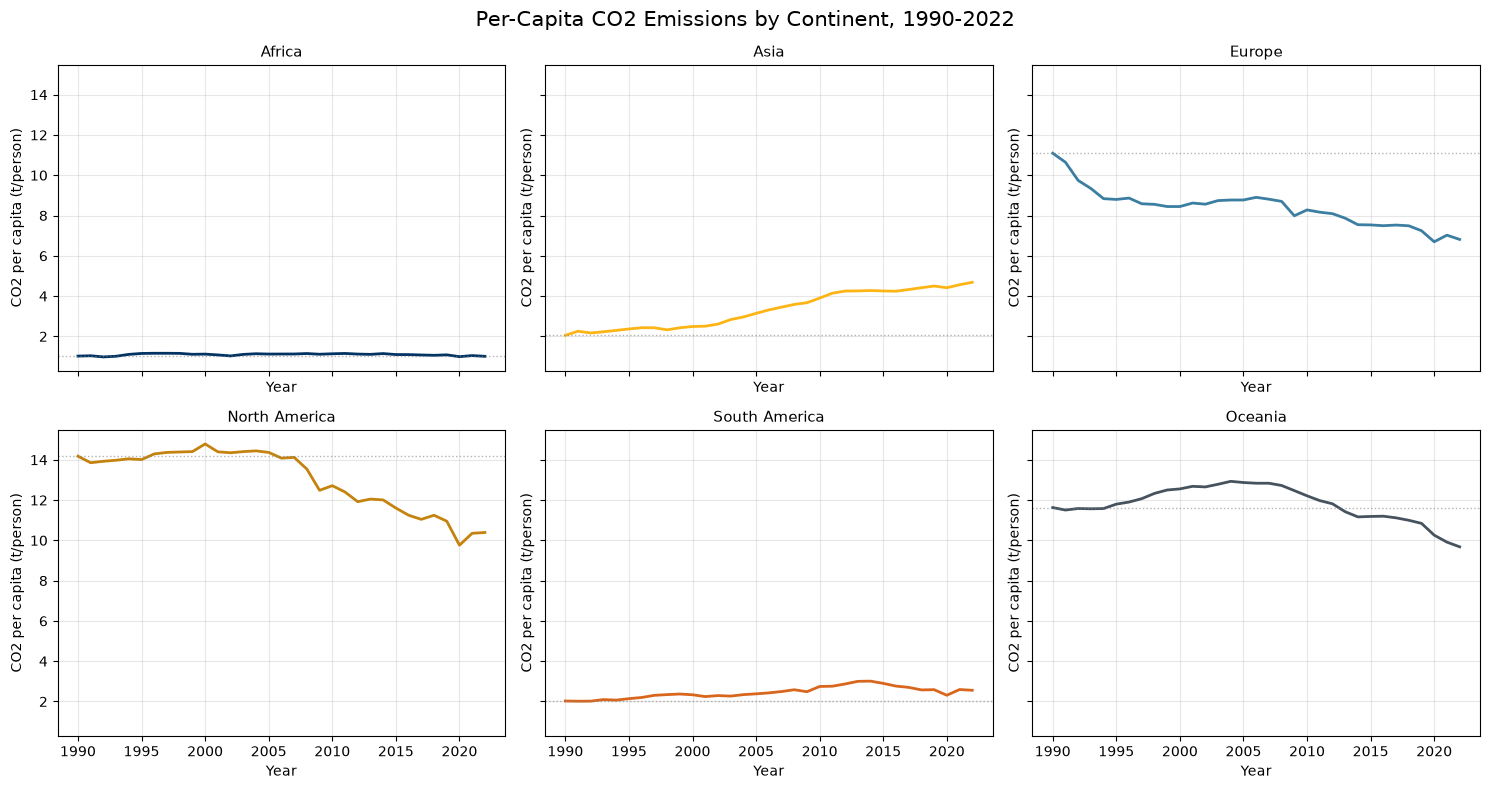

In [23]:
# Task 2.3 - Faceted Visualization
# Small multiples: per-capita CO2 trends (1990-2022), one panel per continent.
# The dataset has no continent column; continents exist as aggregate entities
# with their own co2_per_capita (population-weighted), so we panel those rows.
import matplotlib.pyplot as plt

continents = ["Africa", "Asia", "Europe", "North America", "South America", "Oceania"]

# Per-capita series 1990-2022 for each continent (aggregate rows)
df_cont = df[
    df["country"].isin(continents)
    & df["year"].between(1990, 2022)
    & df["co2_per_capita"].notna()
]

pivot = df_cont.pivot_table(index="year", columns="country", values="co2_per_capita")

# UC Berkeley palette
CAL_BLUE  = "#003262"
CAL_GOLD  = "#FDB515"
BK_BLUE   = "#3B7EA1"
GOLD_DRK  = "#C4820E"
SATHER    = "#D9661D"
FOUNDERS  = "#46535E"
berkeley = [CAL_BLUE, CAL_GOLD, BK_BLUE, GOLD_DRK, SATHER, FOUNDERS]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True, sharex=True)
fig.suptitle("Per-Capita CO2 Emissions by Continent, 1990-2022", fontsize=15)

for ax, (cont, color) in zip(axes.flatten(), zip(continents, berkeley)):
    ax.plot(pivot.index, pivot[cont], linewidth=2, color=color)
    ax.set_title(cont, fontsize=11)
    ax.grid(alpha=0.3)
    ax.axhline(pivot[cont].iloc[0], color="grey", linestyle=":", linewidth=1, alpha=0.6)

for ax in axes.flatten():
    ax.set_xlabel("Year")
    ax.set_ylabel("CO2 per capita (t/person)")

plt.tight_layout()
plt.show()

### My Analysis (Option C):

**Question I'm investigating:** Is there a relationship between population growth and CO2 emissions growth across countries (2000-2022)? Which countries are outliers?

**Method:** Compute 2000→2022 percent growth in population and in total CO2 for real countries (ISO present, both years valid), then a scatter plot with a trend line and annotated outliers. Pearson "r" quantifies the correlation.

Countries analyzed (valid pop+co2 in both years): 213
Pearson r(population growth, CO2 growth) = 0.327


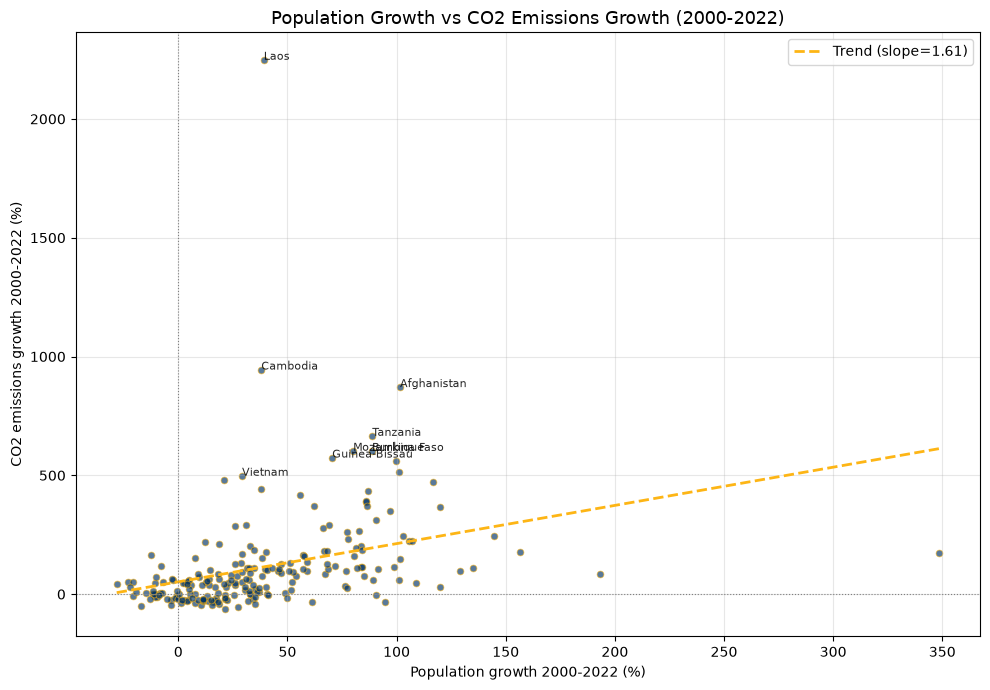

In [24]:
# Task 3.1 - Option C: Population-Emissions Relationship
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Build growth metrics (2000 -> 2022) for real countries ---
sub = df[(df["year"].isin([2000, 2022])) & df["iso_code"].notna()].copy()
pivot = sub.pivot_table(index="country", columns="year",
                        values=["population", "co2"])

# Missing-data handling: require all four values present.
clean = pivot.dropna().copy()
clean.columns = [f"{a}_{b}" for a, b in clean.columns]  # flatten MultiIndex -> pop_2000, co2_2022, ...

clean["pop_growth_pct"] = (clean["population_2022"] / clean["population_2000"] - 1) * 100
clean["co2_growth_pct"] = (clean["co2_2022"] / clean["co2_2000"] - 1) * 100

n = len(clean)
print(f"Countries analyzed (valid pop+co2 in both years): {n}")

# --- 2. Correlation ---
r = np.corrcoef(clean["pop_growth_pct"], clean["co2_growth_pct"])[0, 1]
print(f"Pearson r(population growth, CO2 growth) = {r:.3f}")

# --- 3. Annotated scatter with trend line ---
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(clean["pop_growth_pct"], clean["co2_growth_pct"],
           s=24, alpha=0.65, color="#003262", edgecolor="#FDB515", linewidth=0.6)

m, b = np.polyfit(clean["pop_growth_pct"], clean["co2_growth_pct"], 1)
xs = np.linspace(clean["pop_growth_pct"].min(), clean["pop_growth_pct"].max(), 100)
ax.plot(xs, m * xs + b, color="#FDB515", linestyle="--", linewidth=2,
        label=f"Trend (slope={m:.2f})")

ax.axhline(0, color="grey", linewidth=0.8, linestyle=":")
ax.axvline(0, color="grey", linewidth=0.8, linestyle=":")

ax.set_xlabel("Population growth 2000-2022 (%)")
ax.set_ylabel("CO2 emissions growth 2000-2022 (%)")
ax.set_title("Population Growth vs CO2 Emissions Growth (2000-2022)", fontsize=13)

# Outliers = countries furthest from the y=x line (emitting far above/below population trend)
clean["dist"] = clean["co2_growth_pct"] - clean["pop_growth_pct"]
outliers = clean.reindex(clean["dist"].abs().sort_values(ascending=False).index).head(8)
for _, row in outliers.iterrows():
    ax.annotate(str(row.name),
                xy=(row["pop_growth_pct"], row["co2_growth_pct"]),
                fontsize=8, alpha=0.85)

ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()